In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from doc_chat.evaluation.pdf_util import write_pdf, read_pdf_info


In [2]:
# load the documents
pd_documents = pd.read_csv('../../data/single_topic_rag_evaluation_dataset/raw/documents.csv')
number_of_documents = pd_documents.shape[0]
print(f'Number of documents: {number_of_documents}')
pd_documents

Number of documents: 20


,index,source_url,text
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...


In [3]:
# create pdf files from the documents
out_dir = '../../data/single_topic_rag_evaluation_dataset/processed/pdf_2'

#enable this to write the pdf files
for index, row in pd_documents.iterrows():
    text = row['text']
    write_pdf(text, f"{out_dir}/document_{index}.pdf")

In [4]:
# read number of pages in each PDF file and add it to the DataFrame
for index, row in pd_documents.iterrows():
    pdf_info = read_pdf_info(f"{out_dir}/document_{index}.pdf")
    pd_documents.loc[index, 'num_pages'] = int(pdf_info['num_pages'])
    pd_documents.loc[index, 'total_word_count'] = int(pdf_info['total_word_count'])
    pd_documents.loc[index, 'avg_words_per_page'] = int(pdf_info['avg_words_per_page'])
    pd_documents.loc[index, 'total_char_count'] = int(pdf_info['total_char_count'])
    pd_documents.loc[index, 'avg_chars_per_page'] = int(pdf_info['avg_chars_per_page'])

pd_documents['num_pages'] = pd_documents['num_pages'].astype(int)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,7,1847.0,263.0,10609.0,1515.0
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,470.0,235.0,2737.0,1368.0
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,11,3786.0,344.0,22113.0,2010.0
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,13,3007.0,231.0,20333.0,1564.0
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,11,1797.0,163.0,11257.0,1023.0
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,8,2446.0,305.0,14217.0,1777.0
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,18,5399.0,299.0,35372.0,1965.0
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,10,2973.0,297.0,17889.0,1788.0
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,6,2046.0,341.0,11259.0,1876.0
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,6,2325.0,387.0,13467.0,2244.0


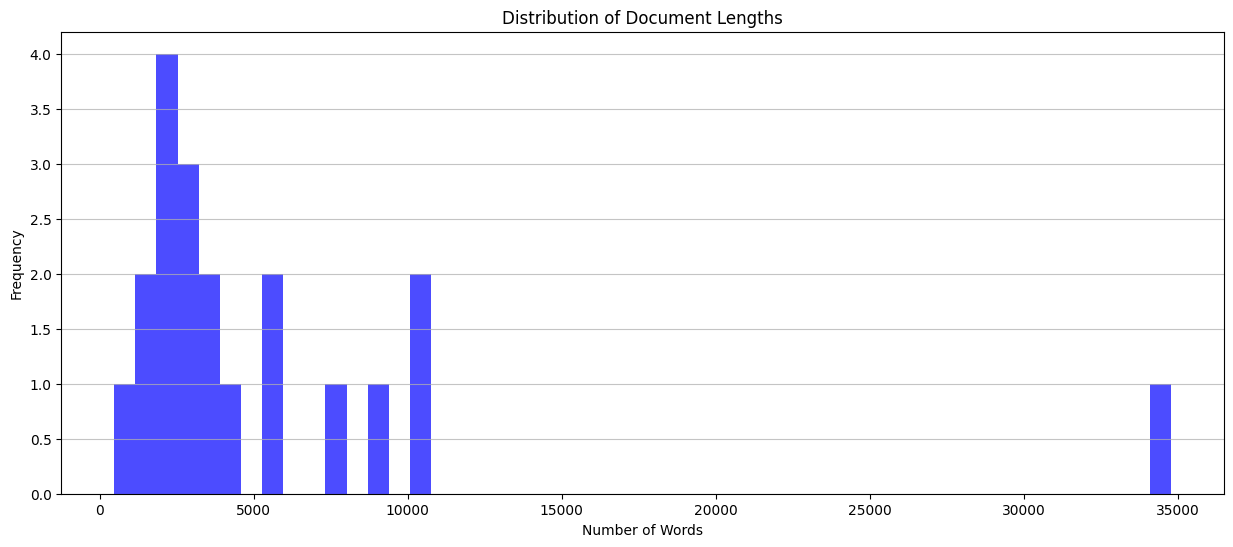

In [5]:
# plot the length of the documents
plt.figure(figsize=(15, 6))
plt.hist(pd_documents['total_word_count'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Document Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [6]:

# write the DataFrame to a CSV file
pd_documents.to_csv('../../data/single_topic_rag_evaluation_dataset/processed/documents_processed_2.csv', index=False)